In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from task_2_3 import (
    calculate_returns,
    rolling_window_analysis,
    expanding_window_analysis
)

from task_9_10 import (
    analyze_portfolio_composition_stability,
    efficient_frontier_dynamics_rolling,
    efficient_frontier_dynamics_expanding,
    efficient_frontier_dynamics_exponential,
    compare_frontier_methods
)

from task_13_14_15 import (
    calculate_market_model_betas,
    calculate_all_betas,
    calculate_covariance_from_betas,
    calculate_residual_variances,
    task_13_covariance_from_historical_betas,
    task_14_efficient_frontier_from_betas,
    task_15_efficient_frontier_dynamics_betas,
    compare_covariance_methods
)

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 100)

import warnings
warnings.filterwarnings('ignore')

### 1. Загрузка и обработка данных

In [2]:
def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    
    df.columns = df.columns.str.strip()
    df['date'] = pd.to_datetime(df['date'], format='%d.%m.%Y')
    df.set_index('date', inplace=True)

    df = df.replace('', np.nan).replace(' ', np.nan) \
            .dropna(how='all') \
            .dropna(axis=1, how='all')
    
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    return df

In [3]:
def load_prices_data(file_path: str) -> pd.DataFrame:
    df = pd.read_csv(file_path, sep=';', decimal=',')

    return preprocess_data(df)

In [4]:
stoks_prices_df = load_prices_data("data/prices_moex_new.csv")

Информация о данных

In [5]:
print(f"Размер: {stoks_prices_df.shape}")
print(f"Период: {stoks_prices_df.index.min()} - {stoks_prices_df.index.max()}")
print(f"Количество акций: {len(stoks_prices_df.columns)}")
print(f"\nСписок акций: {list(stoks_prices_df.columns)}")

Размер: (2763, 30)
Период: 2015-01-05 00:00:00 - 2025-12-30 00:00:00
Количество акций: 30

Список акций: ['SBER', 'SBERP', 'GAZP', 'LKOH', 'ROSN', 'NVTK', 'TATN', 'TATNP', 'SNGS', 'SNGSP', 'GMKN', 'CHMF', 'NLMK', 'MAGN', 'MTSS', 'AFLT', 'VTBR', 'MOEX', 'PLZL', 'ALRS', 'MGNT', 'PHOR', 'AKRN', 'FEES', 'HYDR', 'IRAO', 'BSPB', 'TRNFP', 'SIBN', 'LSRG']


### Доходности

In [6]:
returns = calculate_returns(stoks_prices_df)

Визуализация кумулятивных доходностей для первых 5 акций

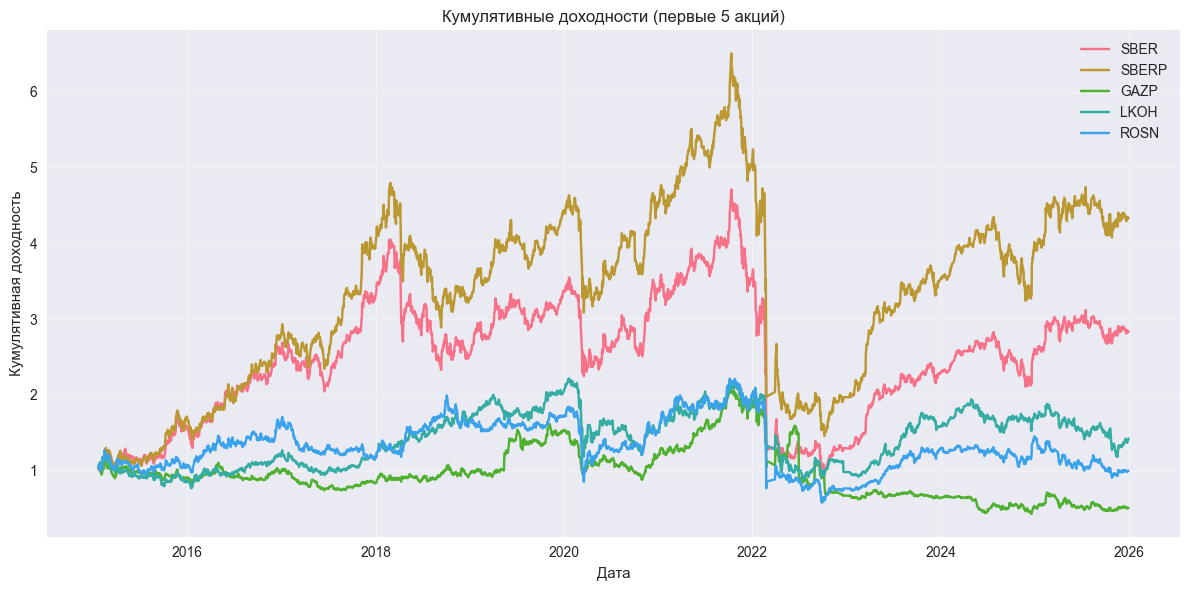

In [10]:
plt.figure(figsize=(12, 6))
for col in returns.columns[:5]:
    cumulative_returns = (1 + returns[col]).cumprod()
    plt.plot(returns.index, cumulative_returns, label=col)

plt.title('Кумулятивные доходности (первые 5 акций)')
plt.xlabel('Дата')
plt.ylabel('Кумулятивная доходность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2. Векторы доходностей и ковариационные матрицы на различные даты

#### 2.a Скользящее окно

In [11]:
rolling_results = rolling_window_analysis(returns, window_size='1Y', step_size='1Y')

In [12]:
print(f"\nПолучено окон: {len(rolling_results)}")

if rolling_results:
    first_date = list(rolling_results.keys())[0]
    first_result = rolling_results[first_date]
    
    print(f"\n--- Первое окно ---")
    print(f"Период: {first_result['window_start'].strftime('%Y-%m-%d')} - {first_date.strftime('%Y-%m-%d')}")
    print(f"Размер окна: {len(first_result['window_returns'])} наблюдений")
    print(f"Размер ковариационной матрицы: {first_result['covariance_matrix'].shape}")
    
    # Проверка ковариационной матрицы
    cov_matrix = first_result['covariance_matrix']
    print(f"\nСвойства ковариационной матрицы:")
    print(f"- Симметричность: {np.allclose(cov_matrix, cov_matrix.T)}")
    print(f"- Определитель: {np.linalg.det(cov_matrix):.6e}")


Получено окон: 10

--- Первое окно ---
Период: 2015-01-21 - 2016-01-21
Размер окна: 251 наблюдений
Размер ковариационной матрицы: (30, 30)

Свойства ковариационной матрицы:
- Симметричность: True
- Определитель: 2.870323e-106


Визуализация динамики средних доходностей во времени

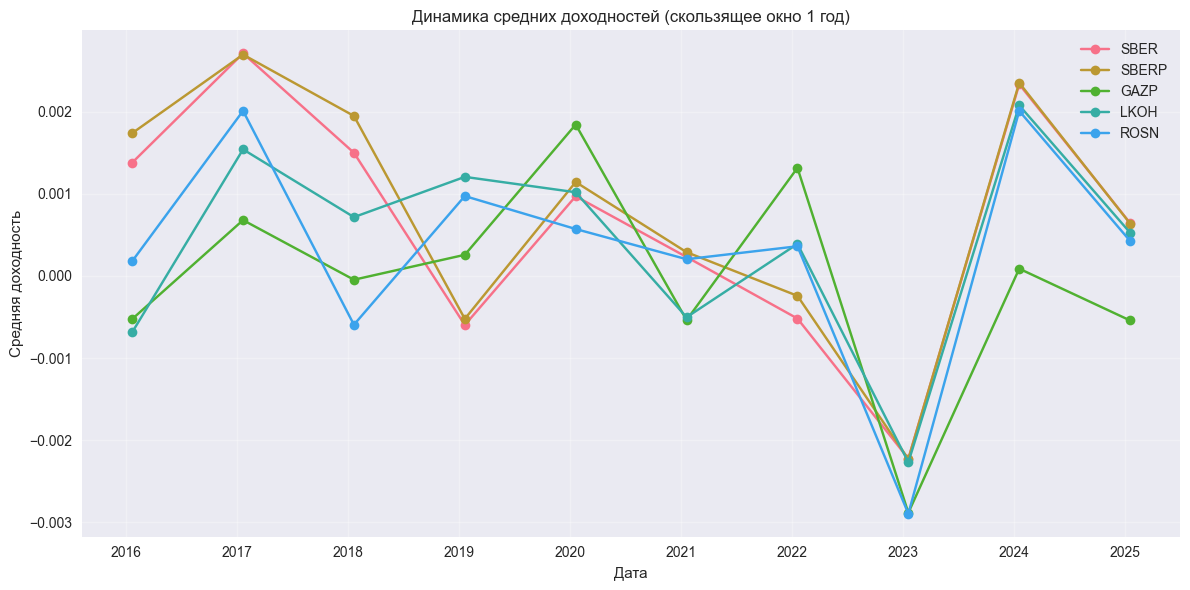

In [13]:
if rolling_results:
    dates = list(rolling_results.keys())
    mean_returns_history = [rolling_results[date]['mean_returns'] for date in dates]
    mean_returns_df = pd.DataFrame(mean_returns_history, index=dates, columns=returns.columns)
    
    plt.figure(figsize=(12, 6))
    for col in returns.columns[:5]:
        plt.plot(mean_returns_df.index, mean_returns_df[col], marker='o', label=col)
    
    plt.title('Динамика средних доходностей (скользящее окно 1 год)')
    plt.xlabel('Дата')
    plt.ylabel('Средняя доходность')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

**Выводы**:
- Определитель матрицы очень мал (~2.87e-106), что характерно для 30x30 матрицы с сильной корреляцией активов
- Средние доходности не стабильны во времени - это демонстрирует, что историческая доходность — ненадежный прогноз будущего

#### 2.b Расширяющее окно

In [14]:
expanding_results = expanding_window_analysis(returns, step_size='1Y')

In [15]:
print(f"\nПолучено окон: {len(expanding_results)}")

if expanding_results:
    print("\n--- Динамика размера окна ---")
    for i, (date, result) in enumerate(list(expanding_results.items())[:5]):
        print(f"Окно {i+1}:  {date.strftime('%Y-%m-%d')} - {result['window_size']} наблюдений")
    print("...")
    
    last_date = list(expanding_results.keys())[-1]
    last_result = expanding_results[last_date]
    print(f"Окно {len(expanding_results)}: {last_date.strftime('%Y-%m-%d')} - {last_result['window_size']} наблюдений")


Получено окон: 10

--- Динамика размера окна ---
Окно 1:  2016-01-21 - 251 наблюдений
Окно 2:  2017-01-20 - 505 наблюдений
Окно 3:  2018-01-20 - 755 наблюдений
Окно 4:  2019-01-20 - 1008 наблюдений
Окно 5:  2020-01-20 - 1260 наблюдений
...
Окно 10: 2025-01-18 - 2475 наблюдений


Сравнение скользящего и расширяющегося окон

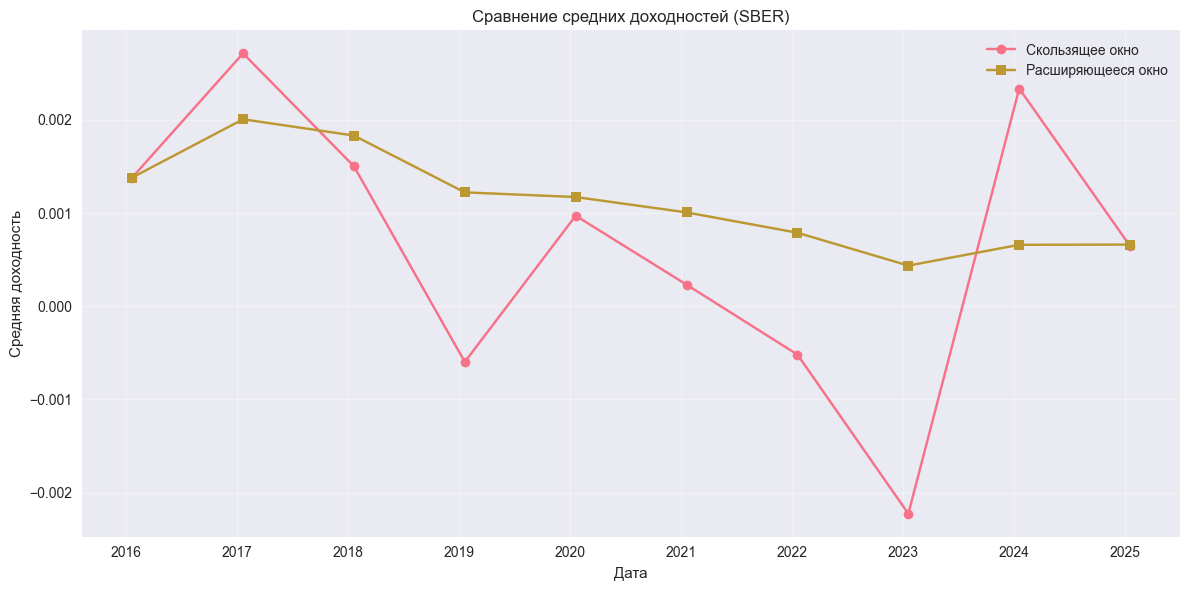

In [16]:
if rolling_results and expanding_results:
    rolling_dates = list(rolling_results.keys())
    expanding_dates = list(expanding_results.keys())
    
    ticker = returns.columns[0]
    
    rolling_means = [rolling_results[date]['mean_returns'][0] for date in rolling_dates]
    expanding_means = [expanding_results[date]['mean_returns'][0] for date in expanding_dates]
    
    plt.figure(figsize=(12, 6))
    plt.plot(rolling_dates, rolling_means, marker='o', label='Скользящее окно')
    plt.plot(expanding_dates, expanding_means, marker='s', label='Расширяющееся окно')
    plt.title(f'Сравнение средних доходностей ({ticker})')
    plt.xlabel('Дата')
    plt.ylabel('Средняя доходность')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

**Выводы**:
- Скользящее окно реагирует быстрее на изменения рыночной ситуации (использует только свежие данные)
- Расширяющееся окно более стабильно (учитывает всю историю), но может отставать от текущих трендов
- Для краткосрочных прогнозов скользящее окно может быть предпочтительнее
- Для долгосрочных оценок — расширяющееся окно

### 3. Экспоненциальное забывание

- Скользящее окно (1 год)
- lambda=0.94

In [17]:
rolling_exp_results = rolling_window_analysis(
    returns, window_size='1Y', step_size='1Y', lambda_param=0.94
)

Сравнение обычного и экспоненциального взвешивания

Получено окон: 10


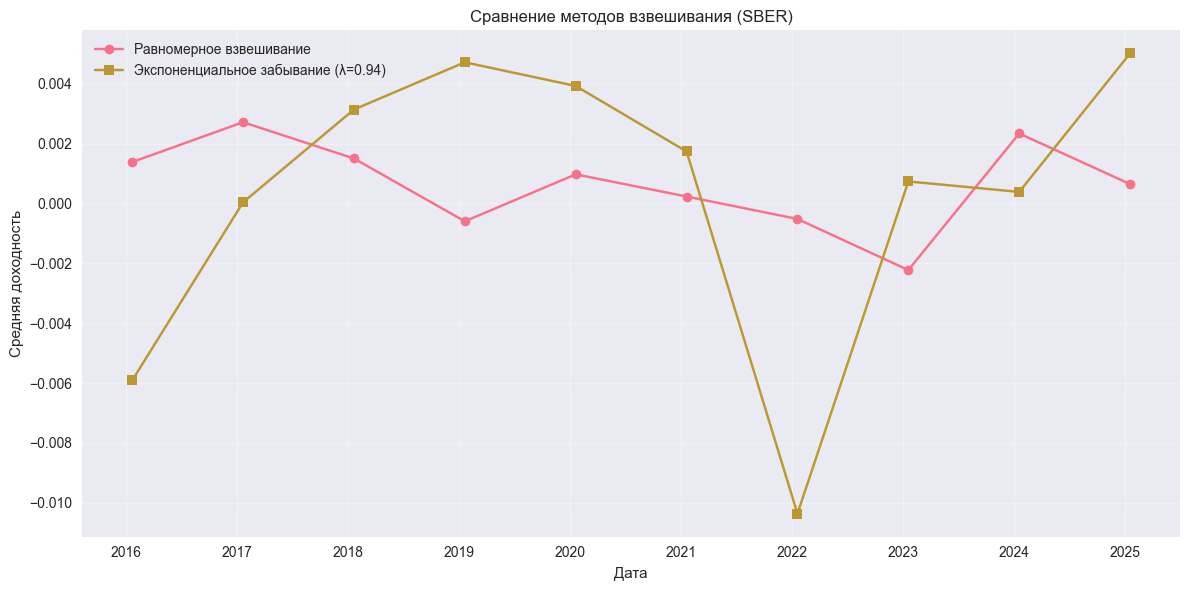


--- Численное сравнение для первой даты ---
Дата: 2016-01-21
Равномерное взвешивание: 0.001382
Экспоненциальное забывание: -0.005912
Разница: -0.007294


In [18]:
print(f"Получено окон: {len(rolling_exp_results)}")

if rolling_results and rolling_exp_results:
    ticker = returns.columns[0]
    ticker_idx = 0
    
    dates = list(rolling_results.keys())
    rolling_means = [rolling_results[date]['mean_returns'][ticker_idx] for date in dates]
    exp_means = [rolling_exp_results[date]['mean_returns'][ticker_idx] for date in dates]
    
    plt.figure(figsize=(12, 6))
    plt.plot(dates, rolling_means, marker='o', label='Равномерное взвешивание')
    plt.plot(dates, exp_means, marker='s', label='Экспоненциальное забывание (λ=0.94)')
    plt.title(f'Сравнение методов взвешивания ({ticker})')
    plt.xlabel('Дата')
    plt.ylabel('Средняя доходность')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\n--- Численное сравнение для первой даты ---")
    first_date = dates[0]
    print(f"Дата: {first_date.strftime('%Y-%m-%d')}")
    print(f"Равномерное взвешивание: {rolling_means[0]:.6f}")
    print(f"Экспоненциальное забывание: {exp_means[0]:.6f}")
    print(f"Разница: {exp_means[0] - rolling_means[0]:.6f}")

**Выводы:**
- Экспоненциальное забывание дает оценки, отличные от равномерного взвешивания
- Различия зависят от конкретной даты и динамики цен
- В периоды стабильности различия могут быть минимальными
- В периоды сильных изменений экспоненциальное забывание быстрее адаптируется

### Общие выводы по блоку
1) Нестабильность оценок: Доходности и риски акций значительно меняются во времени, поэтому статичные оценки могут быть ошибочными
2) Выбор метода взвешивания:
    - Для краткосрочных прогнозов: экспоненциальное забывание или скользящее окно
    - Для долгосрочных стратегий: расширяющееся окно
3) Важность регулярного пересчета: Портфельные веса нужно обновлять с использованием свежих данных
4) Диверсификация: Различия в динамике акций подтверждают важность диверсификации для снижения риска

### Анализ стабильности во времени границы эффективных портфелей

#### 9. Динамика изменения границы эффективных портфелей

##### 9.а Скользящее окно
- Окно: 1 год
- Шаг: 1 год

In [19]:
rolling_frontiers, rolling_stability = efficient_frontier_dynamics_rolling(
    returns, window_size='1Y', step_size='1Y', n_points=50
)

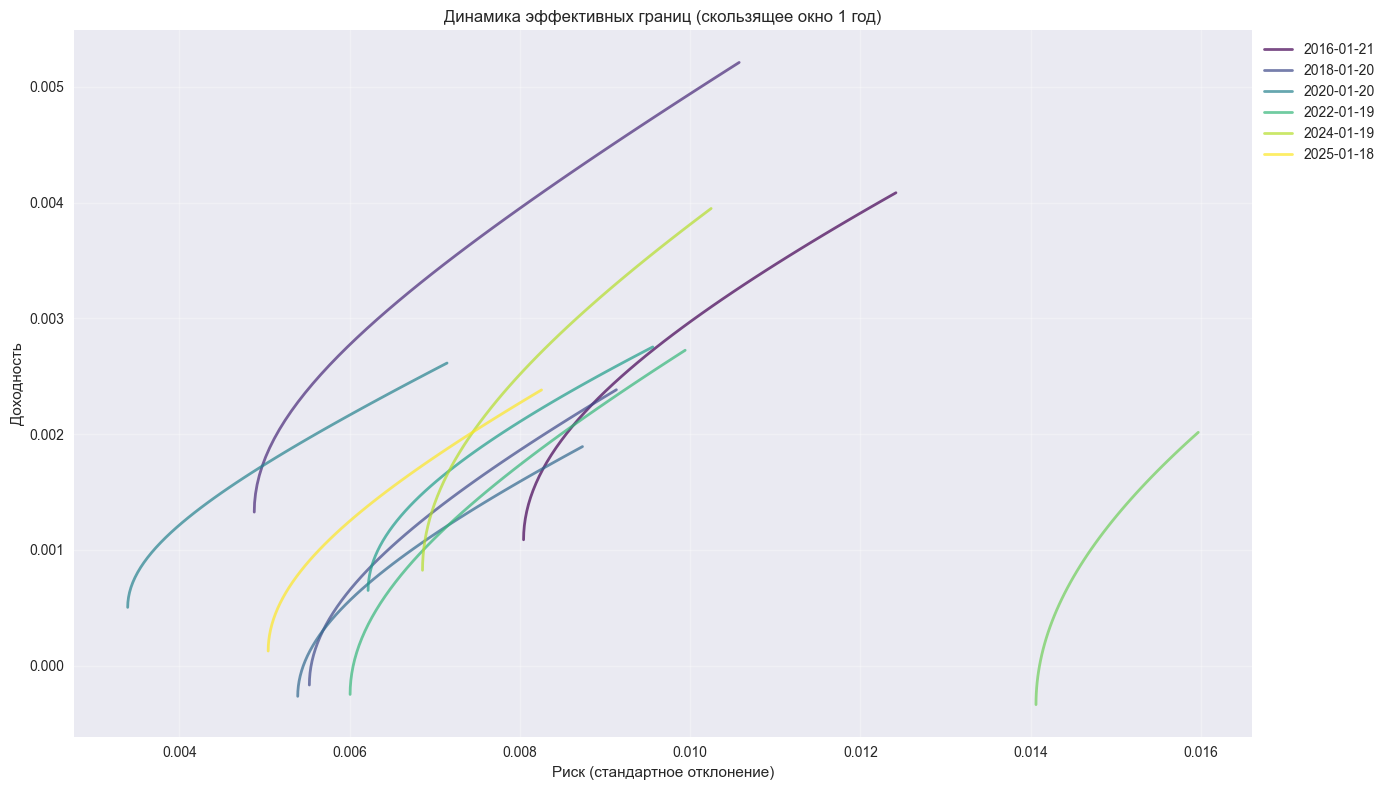

In [20]:
# Визуализация эффективных границ для всех окон
plt.figure(figsize=(14, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(rolling_frontiers)))

for i, (date, frontier) in enumerate(sorted(rolling_frontiers.items())):
    label = date.strftime('%Y-%m-%d') if i % 2 == 0 or i == len(rolling_frontiers) - 1 else None
    plt.plot(frontier['stds'], frontier['returns'], 
             color=colors[i], linewidth=2, alpha=0.7, label=label)

plt.xlabel('Риск (стандартное отклонение)')
plt.ylabel('Доходность')
plt.title('Динамика эффективных границ (скользящее окно 1 год)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

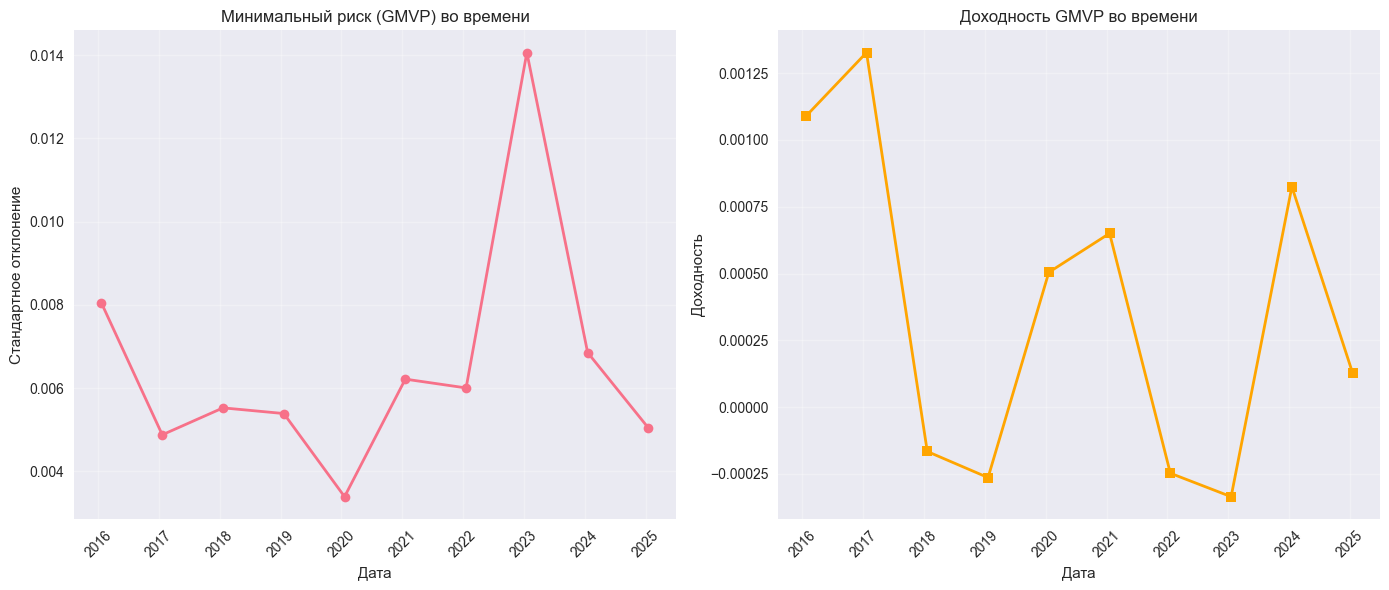

In [21]:
# График динамики минимального риска во времени
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(rolling_stability.index, rolling_stability['min_std'], marker='o', linewidth=2)
plt.title('Минимальный риск (GMVP) во времени')
plt.xlabel('Дата')
plt.ylabel('Стандартное отклонение')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.plot(rolling_stability.index, rolling_stability['min_std_return'], marker='s', linewidth=2, color='orange')
plt.title('Доходность GMVP во времени')
plt.xlabel('Дата')
plt.ylabel('Доходность')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

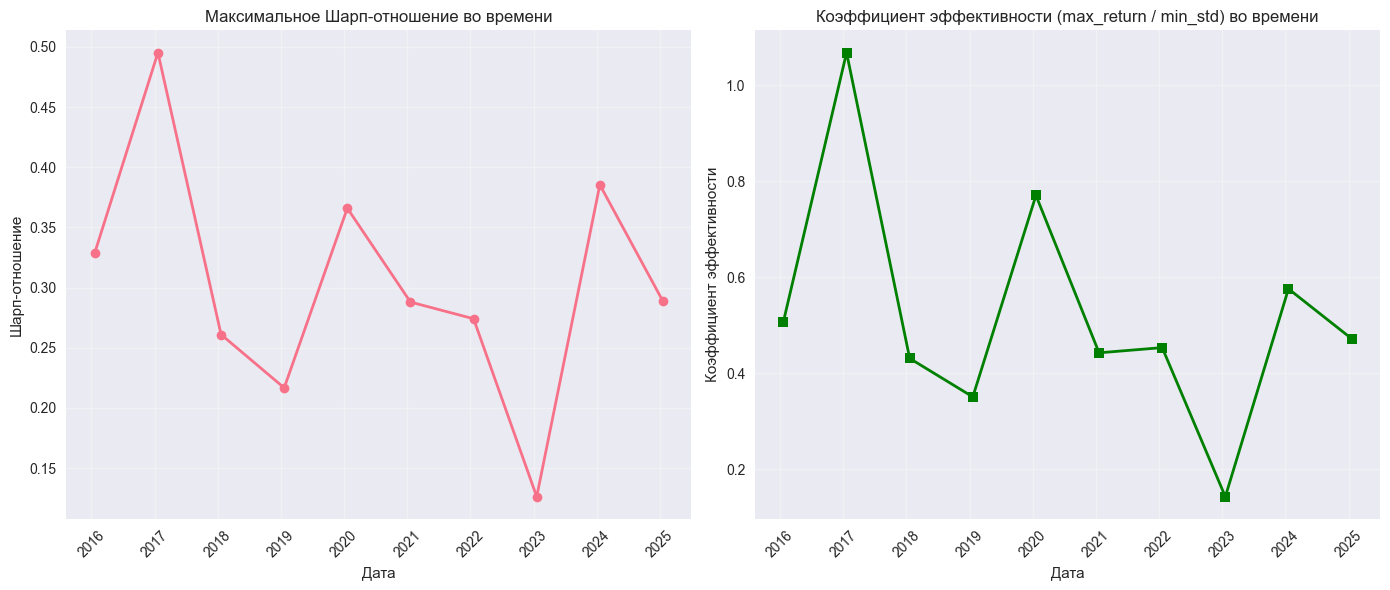

In [22]:
# График динамики максимального Шарпа во времени
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(rolling_stability.index, rolling_stability['max_sharpe'], marker='o', linewidth=2)
plt.title('Максимальное Шарп-отношение во времени')
plt.xlabel('Дата')
plt.ylabel('Шарп-отношение')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.plot(rolling_stability.index, rolling_stability['efficiency_ratio'], marker='s', linewidth=2, color='green')
plt.title('Коэффициент эффективности (max_return / min_std) во времени')
plt.xlabel('Дата')
plt.ylabel('Коэффициент эффективности')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##### 9.b Расширяющееся окно

In [23]:
expanding_frontiers, expanding_stability = efficient_frontier_dynamics_expanding(
    returns, step_size='1Y', n_points=50
)

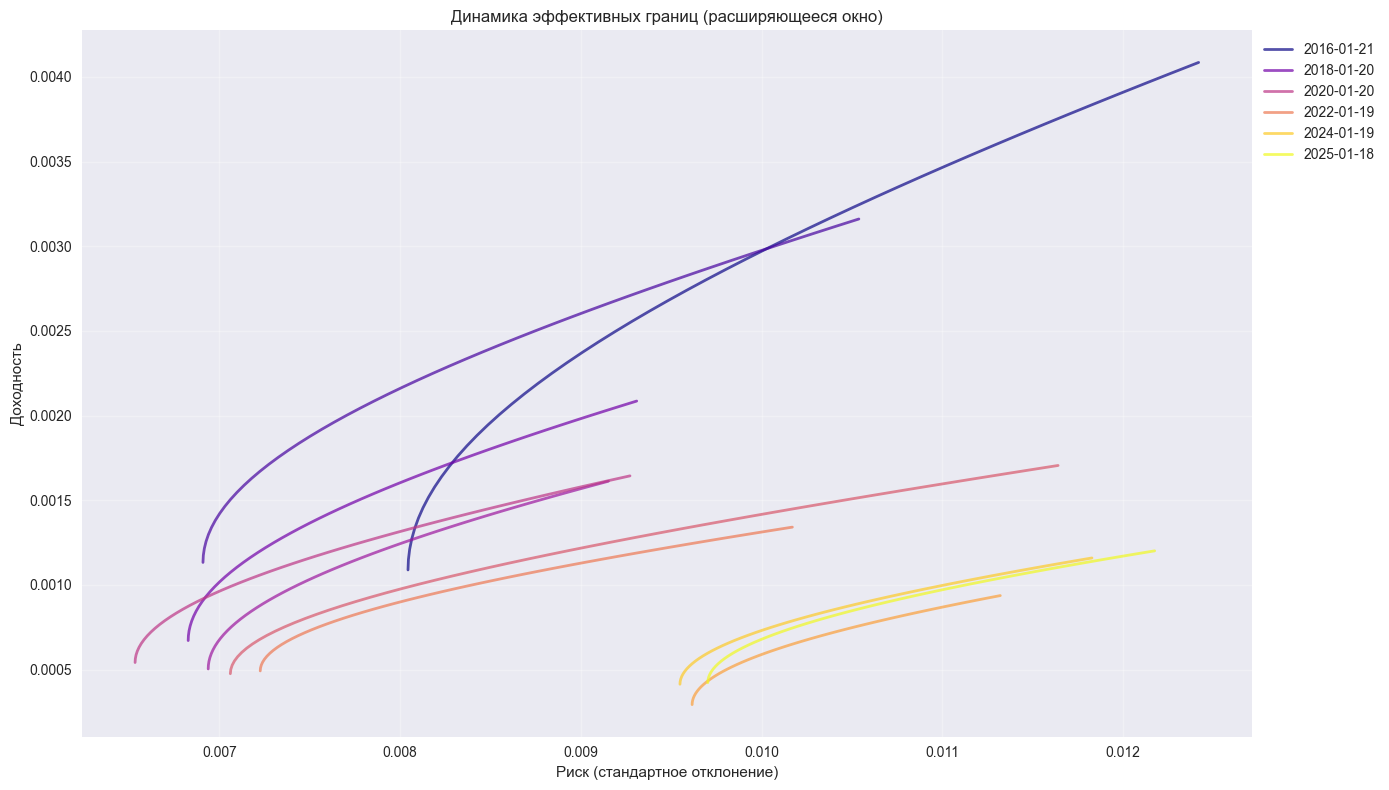

In [24]:
plt.figure(figsize=(14, 8))
colors = plt.cm.plasma(np.linspace(0, 1, len(expanding_frontiers)))

for i, (date, frontier) in enumerate(sorted(expanding_frontiers.items())):
    label = date.strftime('%Y-%m-%d') if i % 2 == 0 or i == len(expanding_frontiers) - 1 else None
    plt.plot(frontier['stds'], frontier['returns'], 
             color=colors[i], linewidth=2, alpha=0.7, label=label)

plt.xlabel('Риск (стандартное отклонение)')
plt.ylabel('Доходность')
plt.title('Динамика эффективных границ (расширяющееся окно)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 10 Экспоненциальное забывание (скользящее окно)

In [25]:
rolling_exp_frontiers, rolling_exp_stability = efficient_frontier_dynamics_exponential(
    returns, window_size='1Y', step_size='1Y', lambda_param=0.94, n_points=50
)

print(f"\nПолучено окон: {len(rolling_exp_frontiers)}")


Получено окон: 10


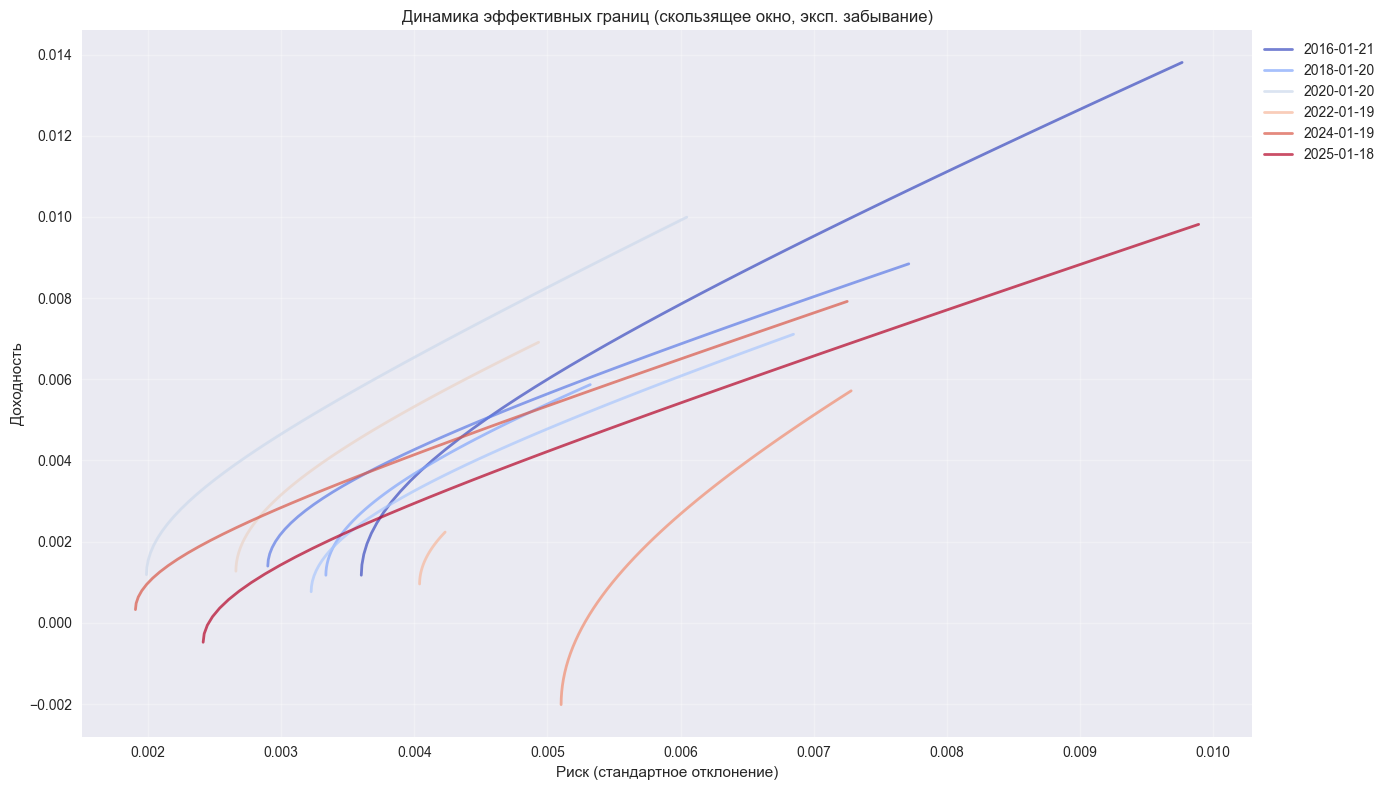

In [26]:
plt.figure(figsize=(14, 8))
colors = plt.cm.coolwarm(np.linspace(0, 1, len(rolling_exp_frontiers)))

for i, (date, frontier) in enumerate(sorted(rolling_exp_frontiers.items())):
    label = date.strftime('%Y-%m-%d') if i % 2 == 0 or i == len(rolling_exp_frontiers) - 1 else None
    plt.plot(frontier['stds'], frontier['returns'], 
             color=colors[i], linewidth=2, alpha=0.7, label=label)

plt.xlabel('Риск (стандартное отклонение)')
plt.ylabel('Доходность')
plt.title('Динамика эффективных границ (скользящее окно, эксп. забывание)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Сравнение методов

In [27]:
comparison = compare_frontier_methods([
    ('Скользящее окно', rolling_frontiers),
    ('Расширяющееся окно', expanding_frontiers),
    ('Скользящее окно (эксп. забывание)', rolling_exp_frontiers)
])

Минимальный риск по методам

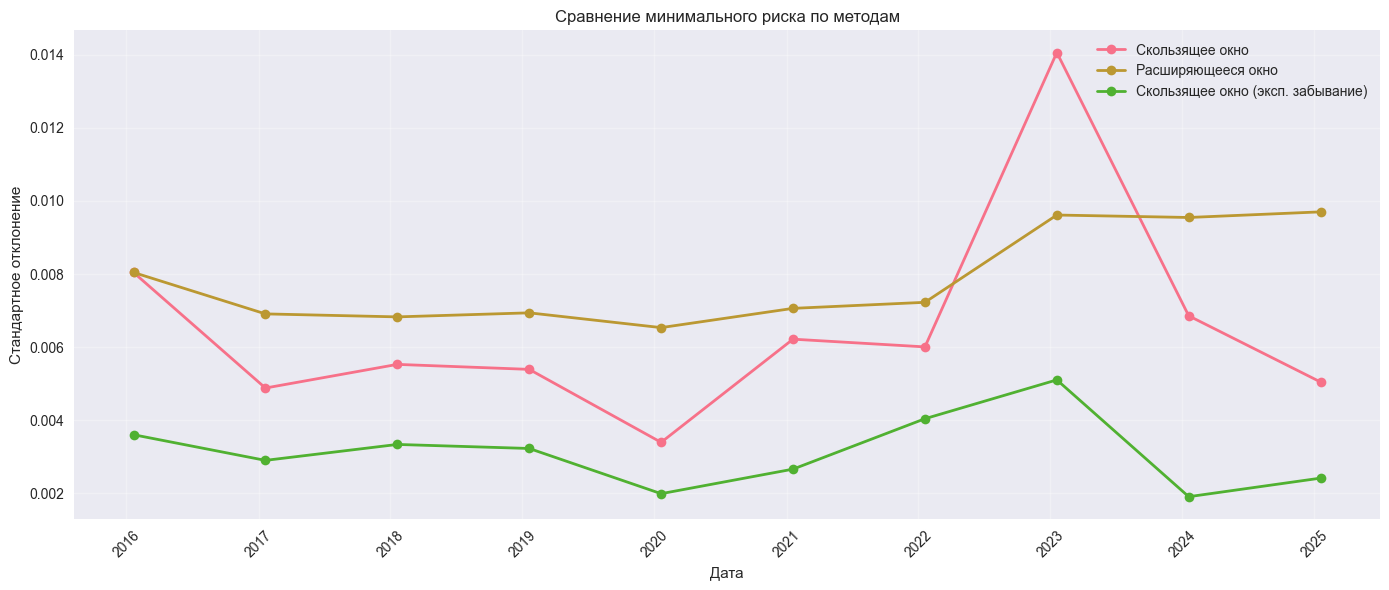

In [28]:
plt.figure(figsize=(14, 6))

for method in comparison.index.get_level_values(0).unique():
    data = comparison.loc[method]
    plt.plot(data.index, data['min_std'], marker='o', linewidth=2, label=method)

plt.title('Сравнение минимального риска по методам')
plt.xlabel('Дата')
plt.ylabel('Стандартное отклонение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Максимальный Шарп по методам

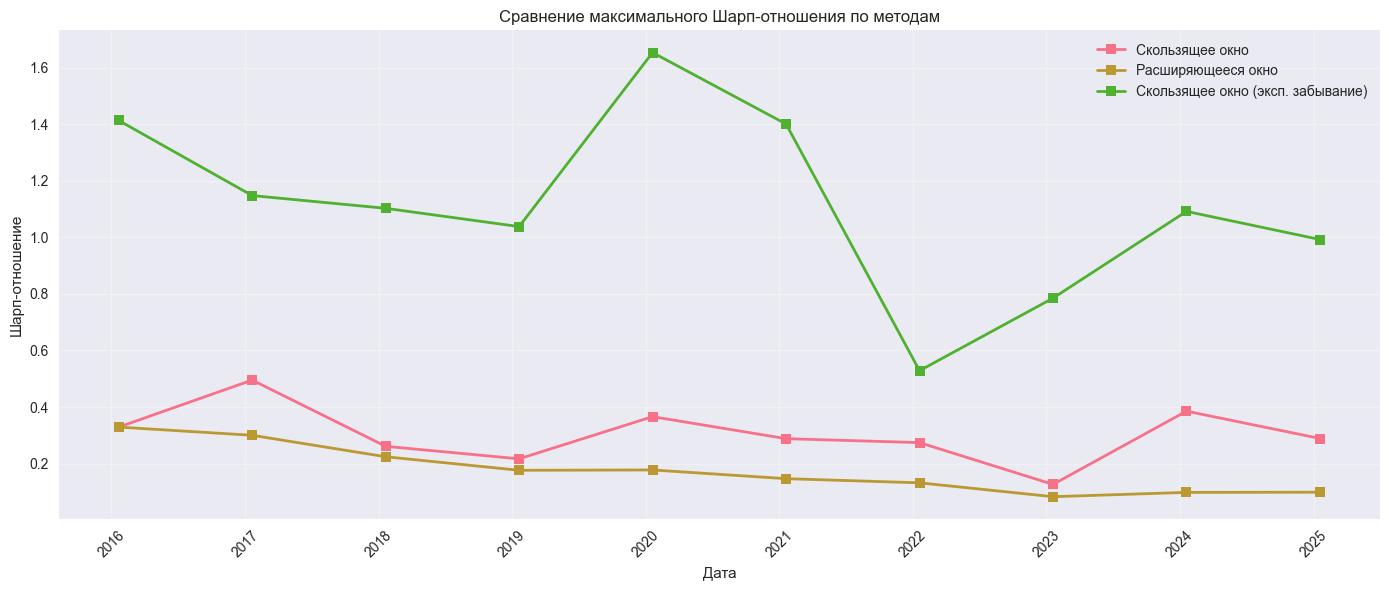

In [29]:
plt.figure(figsize=(14, 6))

for method in comparison.index.get_level_values(0).unique():
    data = comparison.loc[method]
    plt.plot(data.index, data['max_sharpe'], marker='s', linewidth=2, label=method)

plt.title('Сравнение максимального Шарп-отношения по методам')
plt.xlabel('Дата')
plt.ylabel('Шарп-отношение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Анализ стабильности состава портфелей

In [37]:
portfolio_stability = analyze_portfolio_composition_stability(
    rolling_frontiers, returns.columns, percentile=50
)

Динамика весов для первых 5 акций

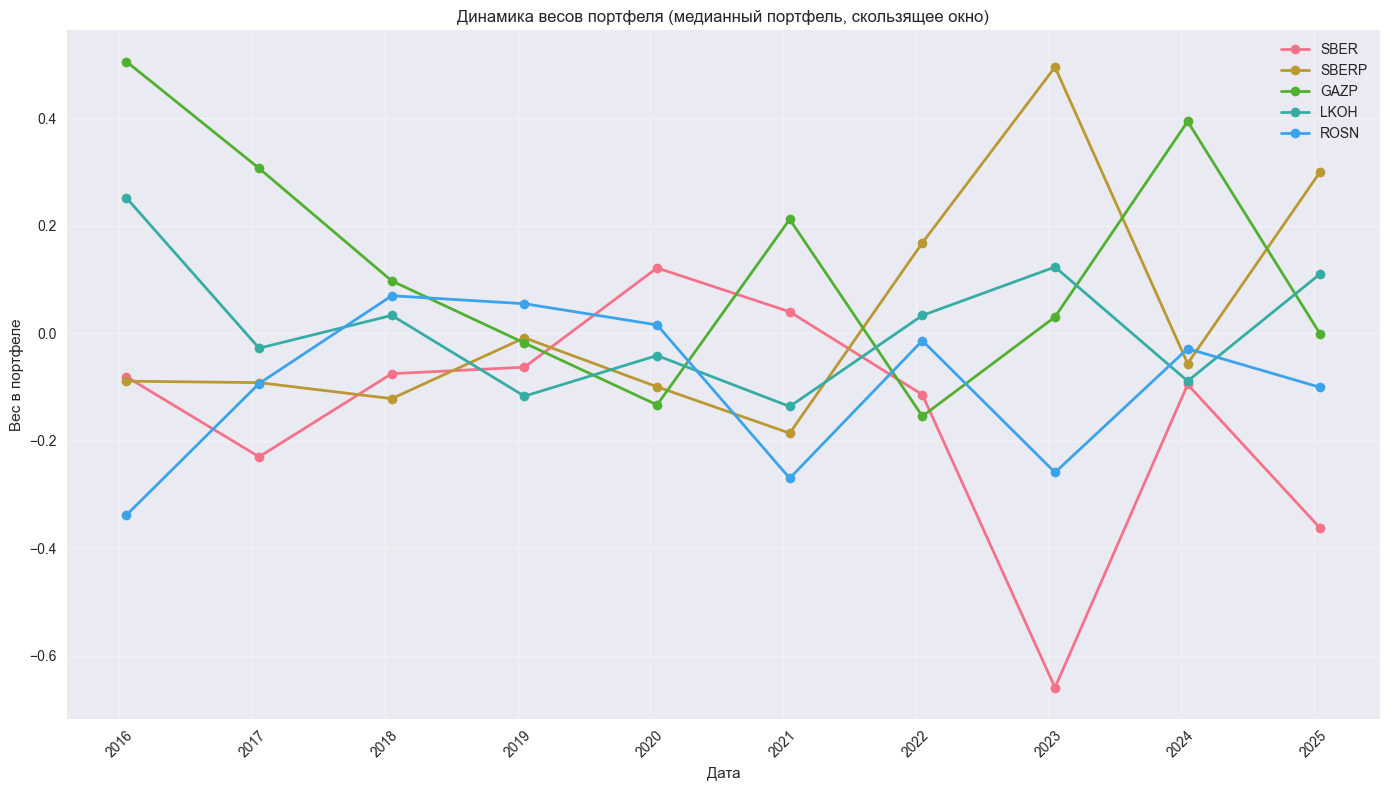

In [ ]:
plt.figure(figsize=(14, 8))

for i, ticker in enumerate(returns.columns[:5]):
    plt.plot(portfolio_stability.index, portfolio_stability[f'w_{ticker}'], 
             marker='o', linewidth=2, label=ticker)

plt.title('Динамика весов портфеля (медианный портфель, скользящее окно)')
plt.xlabel('Дата')
plt.ylabel('Вес в портфеле')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Итоговый анализ

In [33]:
print("=== Итоговый анализ ===")
print(f"\nПериод данных: {returns.index.min()} - {returns.index.max()}")
print(f"Всего наблюдений: {len(returns)}")
print(f"Количество акций: {len(returns.columns)}")

print(f"\n--- Скользящее окно (Задача 9a) ---")
print(f"Количество окон: {len(rolling_frontiers)}")
print(f"Средний минимальный риск: {rolling_stability['min_std'].mean():.6f}")
print(f"Средний макс. Шарп: {rolling_stability['max_sharpe'].mean():.6f}")

print(f"\n--- Расширяющееся окно (Задача 9b) ---")
print(f"Количество окон: {len(expanding_frontiers)}")
print(f"Средний минимальный риск: {expanding_stability['min_std'].mean():.6f}")
print(f"Средний макс. Шарп: {expanding_stability['max_sharpe'].mean():.6f}")

print(f"\n--- Экспоненциальное забывание (Задача 10) ---")
print(f"Количество окон: {len(rolling_exp_frontiers)}")
print(f"Средний минимальный риск: {rolling_exp_stability['min_std'].mean():.6f}")
print(f"Средний макс. Шарп: {rolling_exp_stability['max_sharpe'].mean():.6f}")

=== Итоговый анализ ===

Период данных: 2015-01-21 00:00:00 - 2025-12-30 00:00:00
Всего наблюдений: 2715
Количество акций: 30

--- Скользящее окно (Задача 9a) ---
Количество окон: 10
Средний минимальный риск: 0.006542
Средний макс. Шарп: 0.303003

--- Расширяющееся окно (Задача 9b) ---
Количество окон: 10
Средний минимальный риск: 0.007841
Средний макс. Шарп: 0.176406

--- Экспоненциальное забывание (Задача 10) ---
Количество окон: 10
Средний минимальный риск: 0.003117
Средний макс. Шарп: 1.115510


### Сравнение различных подходов к оценке входящих данных для optimizer

#### 11 Индекс для расчёта исторических и скорректированных β

**Выбранный индекс:** Индекс МосБиржи (IMOEX).
**Обноснование:**
1. Репрезентативность российского рынка. IMOEX является основным индикатором фондового рынка России. Он рассчитывается Московской биржей и включает наиболее ликвидные акции крупнейших российских эмитентов из различных секторов экономики (нефтегазовый, финансовый, металлургический, IT и др.). Использование этого индекса позволяет корректно оценивать систематический риск (бета) относительно всего российского рынка акций.
2. Соответствие данным. Поскольку в проектной работе требуется собрать данные по 30 российским акциям, логично использовать рыночный индекс, рассчитанный на основе того же набора (или расширенного пула) российских ликвидных акций. IMOEX идеально подходит для этой роли.
3. Расчёт в рублях. Индекс МосБиржи рассчитывается в российских рублях . Это исключает необходимость дополнительной конвертации валют при расчёте доходностей акций, которые также торгуются в рублях, и упрощает дальнейшие вычисления.
4. Доступность исторических данных. Для IMOEX доступны полные исторические данные за требуемый период (2015-2025 гг.), что необходимо для выполнения всех последующих этапов работы.

#### 12 Историческое окно и схема взвешивания наблюдений 

**Выбранное историческое окно:** Скользящее окно длиной в 1 год (252 торговых дня).

**Выбранная схема взвешивания:** Равные веса наблюдений (простое скользящее окно).

**Обноснование:**
1.  **Компромисс между актуальностью и стабильностью.** Использование скользящего окна длиной в 1 год является стандартной практикой в финансовой аналитике. С одной стороны, этот период достаточно короткий, чтобы оценки бета-коэффициентов отражали текущие рыночные реалии и структуру бизнеса компании. С другой стороны, он достаточно длинный, чтобы сгладить краткосрочные шумы и получить статистически значимые оценки регрессии.
2.  **Соответствие методике расчёта β.** В пункте 2 задания для расчёта доходностей и ковариационных матриц предлагается использовать скользящее окно длиной в 1 год (как обязательный вариант). Для обеспечения единообразия методологии и возможности корректного сравнения результатов из разных разделов работы логично использовать ту же временную структуру для оценки рыночной модели и расчёта β.
3.  **Простота реализации и интерпретации.** Простое скользящее окно с равными весами является наиболее прозрачным и легко воспроизводимым методом. Это соответствует требованию о "полной воспроизводимости результатов", указанному в задании. Кроме того, это позволит в дальнейшем корректно сравнить границы эффективных портфелей, полученные на основе исторических доходностей (из п. 5), с границами, полученными на основе β-подходов.
4.  **Обоснование для скорректированных β.** Выбранное окно также подходит для расчёта скорректированных β. Скорректированная бета (adjusted beta) рассчитывается на основе исторической ("raw beta"), но сдвигается к среднерыночному значению (1) для учета наблюдаемой на практике тенденции бета-коэффициентов возвращаться к среднему значению . Использование стандартного однолетнего окна для расчёта исторической β, которая затем корректируется по формуле, например, `Adjusted Beta = 0.67 * Raw Beta + 0.33 * 1.0`, является общепринятой практикой .

### Оценка входящих данных для optimizer на основе исторических β

#### Расчет бета для всех акций

In [ ]:
###

#### 13

#### 14

#### 15